Created by Angelo Orletti Del Rey for its masters in psychiatry at Unifesp - SP - Brasil

It was based in our groups previeous works in cotical striatal connectivity in INPD data base of fmri

In [1]:
import numpy as np
import os, sys
import bids
import nibabel as nib
# from scipy.stats import pearsonr
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
# from statsmodels.genmod.families import NegativeBinomial
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt

import argparse
import pandas as pd

from sklearn.preprocessing import StandardScaler

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# from scipy.linalg import LinAlgError

# Suppress convergence warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


In [2]:
def parse():

        options = argparse.ArgumentParser(description="Run 1st level analysis. Created by ...")
        options.add_argument('-p', '--participants', nargs='+',dest="participants", action='store', type=str, required=False,
                            help='id of subject or list of subjects')
        options.set_defaults(participants=None)
        options.add_argument('-w', '--workdir',dest="workdir", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(workdir=os.environ["ROOTDIR"])
        options.add_argument('-b', '--bidsdir',dest="rawdata", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(rawdata=os.path.join(os.environ["ROOTDIR"],"BIDS"))
        options.add_argument('-d', '--derivatives',dest="derivatives", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        options.add_argument('-o', '--outputs',dest="output", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        #print(options.parse_args())

        return options.parse_args()

os.environ["ROOTDIR"] = r'D://'   # seth path
rootdir = os.environ["ROOTDIR"]
if hasattr(sys, "ps1"):
    options = {}
    workdir = os.environ["ROOTDIR"]
    firstleveldir  = os.path.join(workdir,"BIDS","derivatives","first_level_results")
    demographic = os.path.join(workdir,"metadata")
    confounds = os.path.join(workdir,"metadata")
    output = os.path.join(workdir,'second_level_results')
    participants = []

else :
    options = parse()
    participants = options.participants
    workdir = options.workdir
    rawdata = options.rawdata
    derivat = options.derivatives
    output  = options.outputs

print('firstlevel: ', firstleveldir)
    
bidslayout = bids.BIDSLayout(firstleveldir, validate = False) #With validate = True it doesn't find any subjects

if not participants:
    participants = bidslayout.get_subjects() #take all subjects
    #participants_sub = ["sub-" + item for item in participants]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

tmap_allsubj = [] #initialize array for tmaps

print("Loading tmaps for all participants...")
for p in participants:
    #print(f"Subject: {p}")
    p = p.replace("sub-", "")

    # for ses in bidslayout.get_sessions(subject=p):
    #     #print(f"Session: {ses}")                
    
    ses = '1'

    for r in bidslayout.get_runs(subject=p, session=ses):
        #print(f"Run: {r}")

        tmap_metadata = {
            'task': 'rest',
            'suffix': 'tstat',
            'extension': '.txt',
            'run': str(r),
            'session': str(ses),
            'subject': 'sub-'+p,
            'space': 'MNI152NLin2009cAsym',
            'seed': 'SeedtoROI'
        }

        # Save each tmap as a nifti file
        filepath = os.path.join(firstleveldir,tmap_metadata["subject"],"ses-"+tmap_metadata['session'],"func")
        filename = tmap_metadata["subject"] + "_" + \
                    "ses-"+tmap_metadata['session'] + "_" + \
                    "task-"+tmap_metadata['task'] + "_" + \
                    "run-"+tmap_metadata['run'] + "_" + \
                    "space-"+tmap_metadata['space'] + "_" + \
                    "seed-"+tmap_metadata['seed'] + "_" + \
                    tmap_metadata["suffix"] + \
                    tmap_metadata["extension"]
        tmap_path = os.path.join(filepath, filename)

        #load the tmaps for each subject and then append to the tmap_allsubj array
        tmap = pd.read_csv(tmap_path, delimiter=' ', header=None, skiprows=1) #also skips the first row
        tmap.columns = seednames
        tmap_allsubj.append(tmap)

#load socioeconomic and psichometric data for all subjects
print("Loading socioeconomic and psichometric data for all participants...")
socio_psi=pd.read_csv(os.path.join(demographic,'variaveis_analise_conf_nova-exclusão.tsv'), sep='\t')
#substitute in age colunm , to . for decimals if necessary and convert to float
# socio_psi['age'] = socio_psi['age'].str.replace(',', '.').astype(float)

# organinzing the tmaps. Joining the columns of the tmaps for all subjects. So for each subject
# we have to join the first collunm of the first tmap with the first column of the second tmap and so on
# and then join the second column of the first tmap with the second column of the second tmap and so on
# and so on
print("Organizing tmaps...")
tmap_allsubj = pd.concat(tmap_allsubj, axis=1)
tmap_allsubj_organized = {}

for seed in seednames:
    #drop columns with names different from seednames[i]
    tmap_allsubj_organized[seed] = tmap_allsubj.drop(columns=[col for col in tmap_allsubj.columns if col != seed])

# What do we have now: tmap_allsubj_organized is a dictionary with keys being the seednames and values being
# dataframes with the tmaps for all subjects for that seed. This have dimensions of n_ROIs x n_subjects
# Now we have to transpose it to get the data in the format n_subjects x n_ROIs and then join with the
# socioeconomic and psichometric data
# Also, we have to add the sub_id column to the conectivity data to be able to join with the socioeconomic
# and psichometric data
subs = {'sub_id': []}
for p in participants:
    ses = '1'
    if bidslayout.get_runs(subject=p, session=ses) != []:
        subs['sub_id'].append('sub-'+p)

subs = pd.DataFrame(subs)

# create the collunms names for the data frame of rois
roi_names = [f'roi_{i}' for i in range(101)]

for seed in seednames:
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].transpose()
    tmap_allsubj_organized[seed].columns = roi_names
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].reset_index().join(subs, how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['index'])

# Now we have to join the tmaps with the socioeconomic and psichometric data
print("Joining tmaps with socioeconomic and psichometric data...")

for seed in seednames:
    tmap_allsubj_organized[seed] = pd.merge(tmap_allsubj_organized[seed], socio_psi, on='sub_id', how='inner')
    # scaling the data for the regression for the continous variables age, abepscore, cape
    # and for the rois
    # Scale all ROIs
    roi_cols = [f'roi_{i}' for i in range(101)]
    scaler_roi = StandardScaler()
    tmap_allsubj_organized[seed][roi_cols] = scaler_roi.fit_transform(tmap_allsubj_organized[seed][roi_cols])
    
    # Scale age and abepscore together
    scaler_demo = StandardScaler()
    tmap_allsubj_organized[seed][['age', 'abepscore']] = scaler_demo.fit_transform(tmap_allsubj_organized[seed][['age', 'abepscore']])
    


firstlevel:  D://BIDS\derivatives\first_level_results
Loading tmaps for all participants...
Loading socioeconomic and psichometric data for all participants...
Organizing tmaps...
Joining tmaps with socioeconomic and psichometric data...


In [3]:
# plt.hist(tmap_allsubj_organized['DCPutamen']['cape_tot'])

In [4]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confound variables
print("Running regression analysis (salience and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# selecting only the rois that belong to the salience network (name with SalVentAttn) 
# or the default mode network (name with Default)
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default')]
print("Selected ROIs for analysis:", shaeffer_network['index'].tolist())
print("There are", len(shaeffer_network['index'].tolist()), "rois in the salience and default mode network that will be analyzed")

# running the regression analysis for each roi in the salience network
results_networks = {} 
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            
            #running the regression analysis
            # With colection_site and selection as a random effect
            model = smf.mixedlm( f'{cape} ~ roi_{roi} + age  + C(gender)  + abepscore + fd_mean_value+ C(selection)', 
                                data=tmap_allsubj_organized[seed], 
                                groups=tmap_allsubj_organized[seed]["colection_site"])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                # 't-value_selection': fit.tvalues['selection'],
                # 'p-value_selection': fit.pvalues['selection'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                # 'deviance': fit.deviance,
                # 'R_squared_ajusted': fit.rsquared_adj,
                # 'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid,
                # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }
            
            

Running regression analysis (salience and default mode network)...
Selected ROIs for analysis: [24, 25, 26, 27, 28, 29, 30, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 74, 75, 76, 77, 78, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
There are 36 rois in the salience and default mode network that will be analyzed


In [8]:
# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    print(f'Intra CAPE FDR - {cape}')
    
    pvals = []
    keys = []  # <- guardar correspondência
    
    # coletar p-values + chaves
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            pvals.append(results_networks[cape][seed][roi]['p_value'])
            keys.append((seed, roi))
    
    print(f'Number of p-values to correct for {cape}: {len(pvals)}')

    # correção FDR
    corrected = multipletests(pvals, method='fdr_bh')[1]

    # reatribuir corretamente
    for (seed, roi), corr_p in zip(keys, corrected):
        results_networks[cape][seed][roi]['corr_p_value_within_cape'] = corr_p

        if corr_p <= 0.05:
            print(f"###{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

        if corr_p <= 0.10:
            print(f">>>{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

# correcting p-values for all CAPE scores together
# creating a list with all p-values for all CAPE scores to correct them together
# all_p_values = [results_networks[cape][seed][roi]['p_value']
#                  for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']
#                  for seed in seednames
#                  for roi in results_networks[cape][seed].keys()]

# # Correct the p-values for all CAPE scores together
# corrected_p_values_all = multipletests(all_p_values, method='fdr_bh')[1]
# printing the ones that are significant after correcting for all CAPE scores together
# print(f'General FDR - All CAPE scores together')
# index = 0
# for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
#     for seed in seednames:
#         for roi in results_networks[cape][seed].keys():
#             # results_networks[cape][seed][roi]['corr_p_value_general'] = corrected_p_values_all[index]
#             index += 1

            # if results_networks[cape][seed][roi]['corr_p_value_general'] <= 0.05:
            #     print(f"###{cape} roi-{roi} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

print('No FDR Corretion')
# printing the ones that are significant without correcting for all CAPE scores together
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            if results_networks[cape][seed][roi]['p_value'] <= 0.005:
                print(f"### {cape} roi-{roi} -> p_val {results_networks[cape][seed][roi]['p_value']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

#printing the top five highest associations for each CAPE score without correcting for all CAPE scores together
print('---Top 5 associations for each CAPE score without general FDR correction---')
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    associations = []
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            associations.append((results_networks[cape][seed][roi]['coef'], cape, seed, roi, results_networks[cape][seed][roi]['p_value'], results_networks[cape][seed][roi]['t_value'], results_networks[cape][seed][roi]['corr_p_value_within_cape']))
    # Sort the associations by absolute value of the coefficient and get the top 5
    top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
    print(f"Top 5 associations for {cape}:")
    for assoc in top_associations:
        print(f"### {assoc[1]} seed-{assoc[2]} roi-{assoc[3]} -> coef {assoc[0]:.3f} -> p_val {assoc[4]:.3f} -> t-value {assoc[5]:.3f} -> corr_p_val_within_cape {assoc[6]:.3f} ")


Intra CAPE FDR - cape_tot
Number of p-values to correct for cape_tot: 216
>>>cape_tot seed-DRPutamen roi-44 -> corr_p_val_within_cape 0.058 -> Association -0.887 -> t-value -3.645 
Intra CAPE FDR - cape_PA_score
Number of p-values to correct for cape_PA_score: 216
Intra CAPE FDR - cape_PI_score
Number of p-values to correct for cape_PI_score: 216
Intra CAPE FDR - cape_BE_score
Number of p-values to correct for cape_BE_score: 216
No FDR Corretion
### cape_tot roi-44 -> p_val 0.000 -> Association -0.887 -> t-value -3.645 
### cape_tot roi-98 -> p_val 0.003 -> Association -0.736 -> t-value -3.005 
### cape_PA_score roi-98 -> p_val 0.003 -> Association -0.179 -> t-value -2.924 
### cape_PA_score roi-44 -> p_val 0.004 -> Association -0.173 -> t-value -2.875 
### cape_PA_score roi-49 -> p_val 0.005 -> Association -0.169 -> t-value -2.823 
### cape_PI_score roi-50 -> p_val 0.005 -> Association 0.278 -> t-value 2.820 
### cape_PI_score roi-44 -> p_val 0.003 -> Association -0.300 -> t-value -2.

In [14]:
# Merge all regression parameters into a single dataframe grouped by CAPE and seed
all_results = []

for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    # Process salience network results
    for seed in seednames:
        for network in ['SalVentAttn', 'Default']:
            for roi in shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']:
                # Get the result values as a dictionary
                result_dict = results_networks[cape][seed][roi].to_dict('records')[0] if isinstance(results_networks[cape][seed][roi], pd.DataFrame) else results_networks[cape][seed][roi]
                # Add metadata columns
                result_dict['CAPE'] = cape
                result_dict['seed'] = seed
                result_dict['network'] = network
                result_dict['ROI'] = roi
                all_results.append(result_dict)
    

# Create dataframe from list of dictionaries
merged_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = ['CAPE', 'seed', 'network', 'ROI', 'coef', 'intercept', 't_value', 'p_value', 
                'corr_p_value_within_cape', 'AIC', 'BIC',
                'residuals', 'log_likelihood']#, 't-value_selection', 'p-value_selection']
                #'deviance','degrees_of_freedom' ,'mcFadden_R_squared',
merged_df = merged_df[column_order]

# Save to CSV
merged_df.to_csv(os.path.join(output, 'results_2ndlvl_mixedLM_withSelection.csv'), index=False)

# print(f"Merged dataframe saved to: {os.path.join(output, 'results_2ndlvl_OLS_withoutFHS.csv')}")
# print(f"Shape: {merged_df.shape}")
# print(f"\nFirst few rows:")
# print(merged_df.head(10))

In [ ]:
# save the t_map_allsubj_organized for each seed as a csv file
for seed in seednames:
    tmap_allsubj_organized[seed].to_csv(os.path.join(output, f'tmap_allsubj_organized_{seed}.csv'),
                                         index=False)
print(f"Tmaps saved to CSV files in the output directory {output}.")

Tmaps saved to CSV files in the output directory D://second_level_results.


Text(0, 0.5, 'Residual Value')

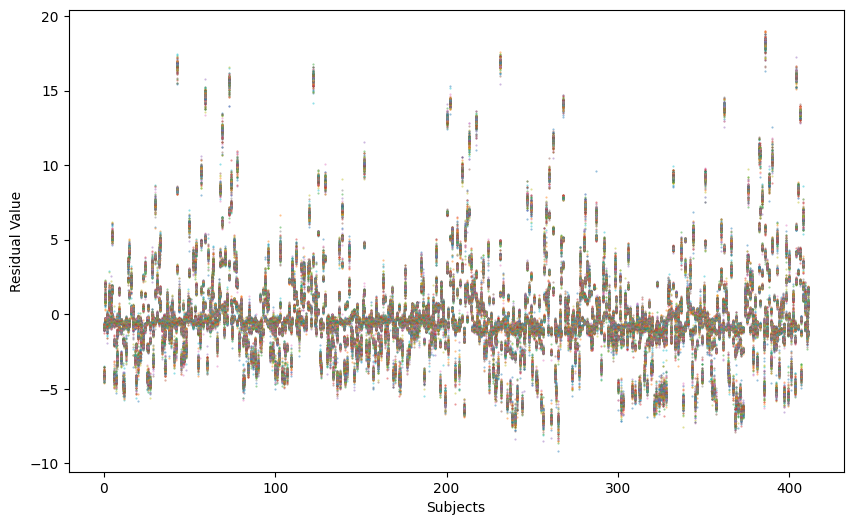

In [ ]:
# plot a summary of the residuals distribution
# merged_df['residuals'][0] #= merged_df['residuals'].apply(lambda x: np.mean(x) if isinstance(x, np.ndarray) else x)
plt.figure(figsize=(10, 6))
for array in merged_df['residuals'].values:
    plt.plot(array, alpha=0.5, marker='o', linestyle='None', markersize=0.5)
# plt.title('Distribution of Residuals')
plt.xlabel('Subjects')
plt.ylabel('Residual Value')


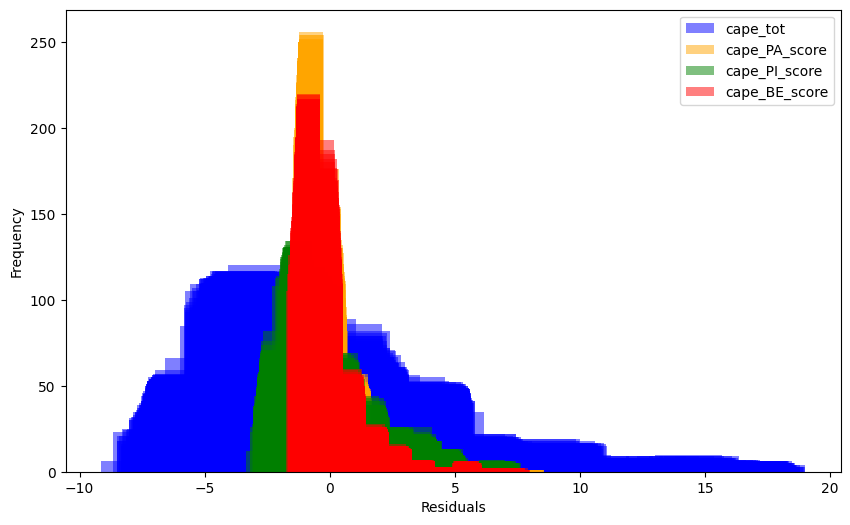

In [ ]:
plt.figure(figsize=(10, 6))
# colapse all residuals of all data frames into a single array and plot the histogram
# add the label in only one of the histograms for each CAPE score
tot, pa, pi, be = False, False, False, False
for cape, array in zip(merged_df['CAPE'], merged_df['residuals'].values):
    
    if cape == 'cape_tot' and not tot:
        plt.hist(array, alpha=0.5, color='blue', label='cape_tot')
        tot = True
    elif cape == 'cape_tot':
        plt.hist(array, alpha=0.5, color='blue')
    elif cape == 'cape_PA_score' and not pa:
        plt.hist(array, alpha=0.5, color='orange', label='cape_PA_score')
        pa = True
    elif cape == 'cape_PA_score':
        plt.hist(array, alpha=0.5, color='orange')
    elif cape == 'cape_PI_score' and not pi:
        plt.hist(array, alpha=0.5, color='green', label='cape_PI_score')
        pi = True
    elif cape == 'cape_PI_score':
        plt.hist(array, alpha=0.5, color='green')
    elif cape == 'cape_BE_score' and not be:
        plt.hist(array, alpha=0.5, color='red', label='cape_BE_score')
        be = True
    elif cape == 'cape_BE_score':
        plt.hist(array, alpha=0.5, color='red')
plt.ylabel('Frequency')
plt.xlabel('Residuals')
plt.legend()
#write mean mean std skewness and kurtosis in the plot
# mean = merged_df['residuals'].apply(lambda x: pd.Series(x).mean() if isinstance(x, np.ndarray) else np.nan).mean()
# std = merged_df['residuals'].apply(lambda x: pd.Series(x).std() if isinstance(x, np.ndarray) else np.nan).mean()
# mean_skewness = merged_df['residuals'].apply(lambda x: pd.Series(x).skew() if isinstance(x, np.ndarray) else np.nan).mean()
# mean_kurtosis = merged_df['residuals'].apply(lambda x: pd.Series(x).kurtosis() if isinstance(x, np.ndarray) else np.nan).mean()
# # put it to a note on the top left
# plt.text(0.05, 0.95, f'Mean: {mean:.2f}\nStd: {std:.2f}\nMean Skewness: {mean_skewness:.2f}\nMean Kurtosis: {mean_kurtosis:.2f}', transform=plt.gca().transAxes, verticalalignment='top')
# plt.title('Distribution of Residuals')

In [29]:
# calculate the effect size for the model of CAPE total score, DRPutamen and ROI 44
cape = 'cape_tot'
seed = 'DRPutamen'
roi = 44

def compute_mixedlm_r2(model):
    import numpy as np

    # -------------------------
    # 1. Extrair X (exog)
    # -------------------------
    X = None

    try:
        X = model.model.exog
    except Exception:
        try:
            X = model.exog
        except Exception:
            try:
                X = model.model.data.exog
            except Exception:
                raise ValueError("Não foi possível acessar a matriz de efeitos fixos (exog).")

    # -------------------------
    # 2. Extrair betas fixos
    # -------------------------
    try:
        beta = model.fe_params.values
    except Exception:
        try:
            beta = model.params.values
        except Exception:
            raise ValueError("Não foi possível acessar os coeficientes fixos.")

    # -------------------------
    # 3. Variância dos efeitos fixos
    # -------------------------
    fitted_fixed = X @ beta
    var_fixed = np.var(fitted_fixed)

    # -------------------------
    # 4. Variância dos efeitos aleatórios
    # -------------------------
    var_random = None

    # tentativa com cov_re
    try:
        cov_re = model.cov_re
        if cov_re is not None:
            var_random = float(np.trace(cov_re))
    except Exception:
        pass

    # fallback empírico
    if var_random is None:
        try:
            re_vals = []
            for v in model.random_effects.values():
                re_vals.append(list(v.values())[0])
            var_random = np.var(re_vals)
        except Exception:
            var_random = 0.0  # fallback extremo

    # -------------------------
    # 5. Variância residual
    # -------------------------
    try:
        var_resid = model.scale
    except Exception:
        try:
            var_resid = model.resid.var()
        except Exception:
            raise ValueError("Não foi possível acessar a variância residual.")

    # -------------------------
    # 6. R²
    # -------------------------
    total = var_fixed + var_random + var_resid

    r2_marginal = var_fixed / total
    r2_conditional = (var_fixed + var_random) / total

    return {
        "r2_marginal": r2_marginal,
        "r2_conditional": r2_conditional,
        "var_fixed": var_fixed,
        "var_random": var_random,
        "var_residual": var_resid
    }

model = smf.mixedlm( f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value', 
                            data=tmap_allsubj_organized[seed],
                            groups=tmap_allsubj_organized[seed]["colection_site"])
fit = model.fit()

# calculate standardized beta for the variable of interest (roi_44)
std_beta = fit.params[f'roi_{roi}'] * (tmap_allsubj_organized[seed][f'roi_{roi}'].std() / tmap_allsubj_organized[seed][cape].std())
print(f'Standardized Beta for {cape}, {seed}, roi_{roi}: {std_beta:.3f}')

r2_results = compute_mixedlm_r2(fit)
print(f"R² Marginal: {r2_results['r2_marginal']:.3f}")
print(f"R² Conditional: {r2_results['r2_conditional']:.3f}")


model = smf.mixedlm( f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(selection)', 
                            data=tmap_allsubj_organized[seed],
                            groups=tmap_allsubj_organized[seed]["colection_site"])
fit = model.fit()

# calculate standardized beta for the variable of interest (roi_44)
std_beta = fit.params[f'roi_{roi}'] * (tmap_allsubj_organized[seed][f'roi_{roi}'].std() / tmap_allsubj_organized[seed][cape].std())
print(f'Standardized Beta for {cape}, {seed}, roi_{roi}: {std_beta:.3f}')
r2_results = compute_mixedlm_r2(fit)
print(f"R² Marginal: {r2_results['r2_marginal']:.3f}")
print(f"R² Conditional: {r2_results['r2_conditional']:.3f}")



Standardized Beta for cape_tot, DRPutamen, roi_44: -0.178
R² Marginal: 0.059
R² Conditional: 0.205
Standardized Beta for cape_tot, DRPutamen, roi_44: -0.173
R² Marginal: 0.061
R² Conditional: 0.207


In [9]:
# check if selection is a colider bias, just for CAPE total score, DRPutamen and ROI 44
model_selection = smf.mixedlm( f'cape_tot ~ age  + C(gender)  + abepscore + fd_mean_value+ C(selection)', 
                            data=tmap_allsubj_organized['DRPutamen'],
                            groups=tmap_allsubj_organized['DRPutamen']["colection_site"])
fit_selection = model_selection.fit()
print(fit_selection.summary())


model_selection = smf.mixedlm( f'roi_44 ~ age  + C(gender)  + abepscore + fd_mean_value+ C(selection)', 
                            data=tmap_allsubj_organized['DRPutamen'],
                            groups=tmap_allsubj_organized['DRPutamen']["colection_site"])
fit_selection = model_selection.fit()
print(fit_selection.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  cape_tot  
No. Observations:    412      Method:              REML      
No. Groups:          2        Scale:               23.7585   
Min. group size:     198      Log-Likelihood:      -1234.2838
Max. group size:     214      Converged:           Yes       
Mean group size:     206.0                                   
-------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------------
Intercept          3.439    1.670  2.059 0.039   0.165  6.712
C(gender)[T.2]     1.559    0.489  3.190 0.001   0.601  2.516
C(selection)[T.2]  0.687    0.484  1.419 0.156  -0.262  1.636
age               -0.122    0.245 -0.497 0.619  -0.603  0.359
abepscore         -0.510    0.242 -2.103 0.035  -0.985 -0.035
fd_mean_value      1.428    6.589  0.217 0.828 -11.486 14.343
Group Var          3

collumns of the encoded dataframe:  Index(['age', 'abepscore', 'fd_mean_value', 'colection_site_2.0',
       'selection_2', 'gender_2', 'CAPE_total', 'CAPE_PA', 'CAPE_PI',
       'CAPE_BE', 'roi_44 DRPutamen'],
      dtype='object')
head of the encoded dataframe:          age  abepscore  fd_mean_value  colection_site_2.0  selection_2  \
0 -0.984018  -1.865980       0.072094                   0            0   
1  1.062728   0.161879       0.118437                   0            0   
2  0.441446  -1.190027       0.129256                   0            1   
3  1.727558  -1.415345       0.084091                   0            0   
4 -1.410787  -0.514074       0.105092                   0            0   

   gender_2  CAPE_total  CAPE_PA  CAPE_PI  CAPE_BE  roi_44 DRPutamen  
0         1         1.0      0.0      1.0      0.0         -0.948073  
1         1         5.0      0.0      4.0      0.0          0.849851  
2         1         4.0      0.0      2.0      0.0          0.277782  
3     

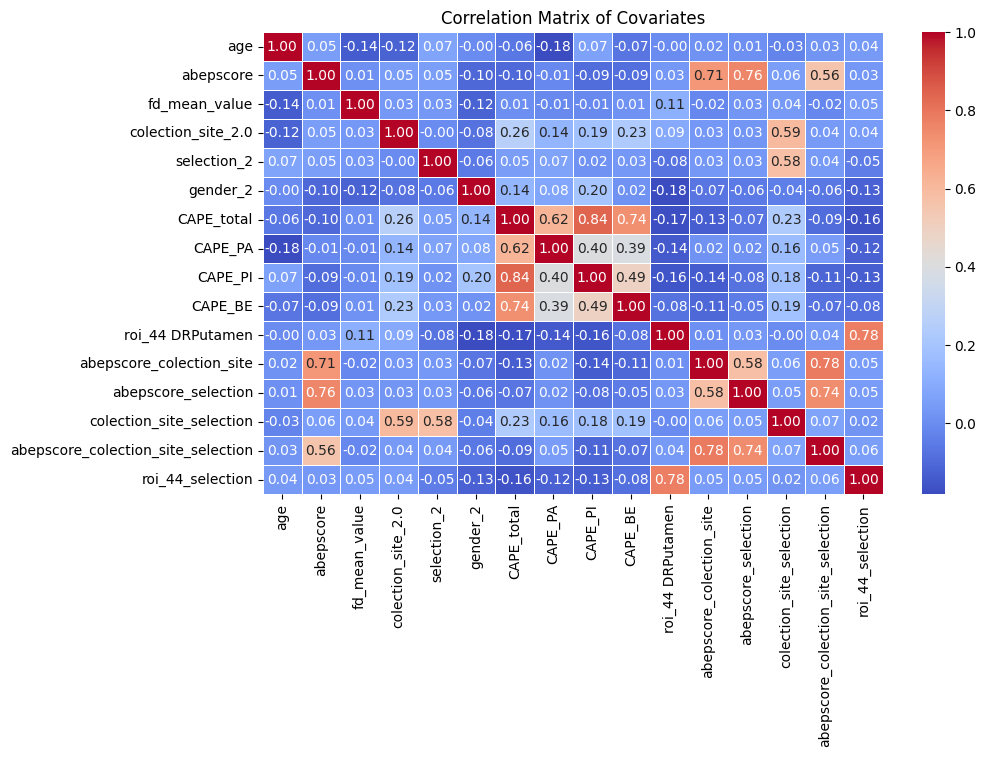

                              variavel        VIF
0                                  age   1.116085
1                            abepscore   4.471824
2                        fd_mean_value   4.397477
3                   colection_site_2.0   4.119311
4                          selection_2   3.951857
5                             gender_2   1.917411
6                           CAPE_total  17.787634
7                              CAPE_PA   2.446622
8                              CAPE_PI   8.065000
9                              CAPE_BE   3.466202
10                    roi_44 DRPutamen   2.694919
11            abepscore_colection_site   4.925470
12                 abepscore_selection   4.780486
13            colection_site_selection   4.166422
14  abepscore_colection_site_selection   5.275515
15                    roi_44_selection   2.596290


In [12]:
# Compute and visualize correlations between covariates
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'merged_df' contains your data; adjust if needed
variables = ['age', 'gender', 'abepscore', 'colection_site', 'fd_mean_value', 'selection']
# do an one hot encoding on the variables colection_site, selection and gender to be able to compute the correlation matrix
merged_df_encoded = pd.get_dummies(tmap_allsubj_organized['DRPutamen'][variables], columns=['colection_site', 'selection', 'gender'], drop_first=True)

# add the collumns age abepscore and fd_mean_value to the encoded dataframe
merged_df_encoded['age'] = tmap_allsubj_organized['DRPutamen']['age']
merged_df_encoded['abepscore'] = tmap_allsubj_organized['DRPutamen']['abepscore']
merged_df_encoded['fd_mean_value'] = tmap_allsubj_organized['DRPutamen']['fd_mean_value']
merged_df_encoded['CAPE_total'] = tmap_allsubj_organized['DRPutamen']['cape_tot']
merged_df_encoded['CAPE_PA'] = tmap_allsubj_organized['DRPutamen']['cape_PA_score']
merged_df_encoded['CAPE_PI'] = tmap_allsubj_organized['DRPutamen']['cape_PI_score']
merged_df_encoded['CAPE_BE'] = tmap_allsubj_organized['DRPutamen']['cape_BE_score']
merged_df_encoded['roi_44 DRPutamen'] = tmap_allsubj_organized['DRPutamen']['roi_44']
print('collumns of the encoded dataframe: ', merged_df_encoded.columns)
print('head of the encoded dataframe: ', merged_df_encoded.head())

# create an interaction term between abepscore colection_site and selection
merged_df_encoded['abepscore_colection_site'] = merged_df_encoded['abepscore'] * merged_df_encoded['colection_site_2.0']
merged_df_encoded['abepscore_selection'] = merged_df_encoded['abepscore'] * merged_df_encoded['selection_2']
merged_df_encoded['colection_site_selection'] = merged_df_encoded['colection_site_2.0'] * merged_df_encoded['selection_2']
merged_df_encoded['abepscore_colection_site_selection'] = merged_df_encoded['abepscore'] * merged_df_encoded['colection_site_2.0'] * merged_df_encoded['selection_2']
merged_df_encoded['roi_44_selection'] = merged_df_encoded['roi_44 DRPutamen'] * merged_df_encoded['selection_2']
corr_matrix = merged_df_encoded.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Covariates')
plt.show()

vif = pd.DataFrame()
vif["variavel"] = merged_df_encoded.columns
vif["VIF"] = [variance_inflation_factor(merged_df_encoded.values, i) for i in range(merged_df_encoded.shape[1])]

print(vif)

In [ ]:
# running a PCA for all the covariates to see if we can reduce the dimensionality of the covariates and avoid multicollinearity
from sklearn.decomposition import PCA
pca = PCA(n_components=5)  # Adjust n_components as needed
covariate_columns = ['age', 'abepscore', 'fd_mean_value', 'colection_site_2.0', 'selection_2', 'gender_2']
print('Covariate columns for PCA:', covariate_columns)
covariate_data = merged_df_encoded[covariate_columns]
pca_result = pca.fit_transform(covariate_data)
print(f'Explained variance by each principal component: {pca.explained_variance_ratio_}')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum()}')
# describe what is the contribuition of each original variable to the principal components
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=covariate_columns)
print('PCA Loadings:\n', loadings)

Covariate columns for PCA: ['age', 'abepscore', 'fd_mean_value', 'colection_site_2.0', 'selection_2', 'gender_2']
Explained variance by each principal component: [0.3847805  0.34710316 0.09701834 0.08882281 0.08179219]
Total explained variance: 0.9995170036446818
PCA Loadings:
                          PC1       PC2       PC3       PC4       PC5
age                 0.707855 -0.700104 -0.026951  0.084473 -0.030118
abepscore           0.701885  0.706780  0.087481 -0.000508 -0.012868
fd_mean_value      -0.003112  0.004242 -0.007433 -0.001635  0.005072
colection_site_2.0 -0.029567  0.085930 -0.543526  0.568892 -0.610478
selection_2         0.056712 -0.008050 -0.448230 -0.814511 -0.363832
gender_2           -0.046889 -0.053387  0.703729 -0.076126 -0.702741
